In [1]:
from bs4 import BeautifulSoup
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torchtext.vocab import build_vocab_from_iterator
import nltk
from nltk.tokenize import word_tokenize
import os
import tqdm

/Users/alfred/anaconda3/envs/ml/lib/python3.9/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/Users/alfred/anaconda3/envs/ml/lib/python3.9/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [1]:
!pip show torch
!pip show torchtext

Name: torch
Version: 2.1.0.dev20230820
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3
Location: /Users/alfred/anaconda3/envs/ml/lib/python3.9/site-packages
Requires: filelock, fsspec, jinja2, networkx, sympy, typing-extensions
Required-by: accelerate, retriv, sentence-transformers, torchaudio, torchtext, torchvision
Name: torchtext
Version: 0.18.0
Summary: Text utilities, models, transforms, and datasets for PyTorch.
Home-page: https://github.com/pytorch/text
Author: PyTorch Text Team
Author-email: packages@pytorch.org
License: BSD
Location: /Users/alfred/anaconda3/envs/ml/lib/python3.9/site-packages
Requires: numpy, requests, torch, tqdm
Required-by: 


In [2]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/alfred/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
regex = re.compile(r"\((\d+), '([^']+)', '([^']+)', (\d+), ('[^']+'\))")

mapper = dict()

with open('n96ncsr5g4-1/index.txt', 'r') as file:
    fields = file.readlines()
    for field in fields:
        match = re.match(regex, field)
        if match:
            mapper[match.group(3)] = match.group(4)

print(len(mapper))


79987


In [4]:
files = []

for part in range(1, 7):  # Dataset parts 1 to 6
    dataset_path = f'n96ncsr5g4-1/dataset/dataset-part-{part}'
    for file in os.listdir(dataset_path):
        full_path = f'{dataset_path}/{file}'
        files.append(full_path)

X = []
y = []
max_files = 1000

for file in tqdm.tqdm(files[:max_files]):
    # Extract the filename from the full path
    filename = file.split('/')[-1]
    if filename in mapper:
        with open(file, 'r') as file:
            html_content = file.read()
            soup = BeautifulSoup(html_content, 'html.parser')
            text = soup.get_text()
            text = text.strip()
            X.append(text)
            y.append(mapper[filename])

100%|██████████| 1000/1000 [00:13<00:00, 76.39it/s]


In [5]:
print(files[960])
print(y[960])

n96ncsr5g4-1/dataset/dataset-part-1/10003990.html
0


### Exploratory Data Analysis

       File Index     Word Count  Character Count  Unique Word Count  \
count  961.000000     961.000000       961.000000         961.000000   
mean   480.000000    1182.448491     12192.201873         390.155047   
std    277.561104    4263.405847     28177.876775        1494.429226   
min      0.000000       0.000000         0.000000           0.000000   
25%    240.000000      49.000000       581.000000          38.000000   
50%    480.000000     332.000000      3936.000000         171.000000   
75%    720.000000    1179.000000     14121.000000         479.000000   
max    960.000000  107141.000000    567856.000000       44078.000000   

       Unique Character Count  
count              961.000000  
mean                65.917794  
std                 44.410614  
min                  0.000000  
25%                 42.000000  
50%                 68.000000  
75%                 82.000000  
max                614.000000  


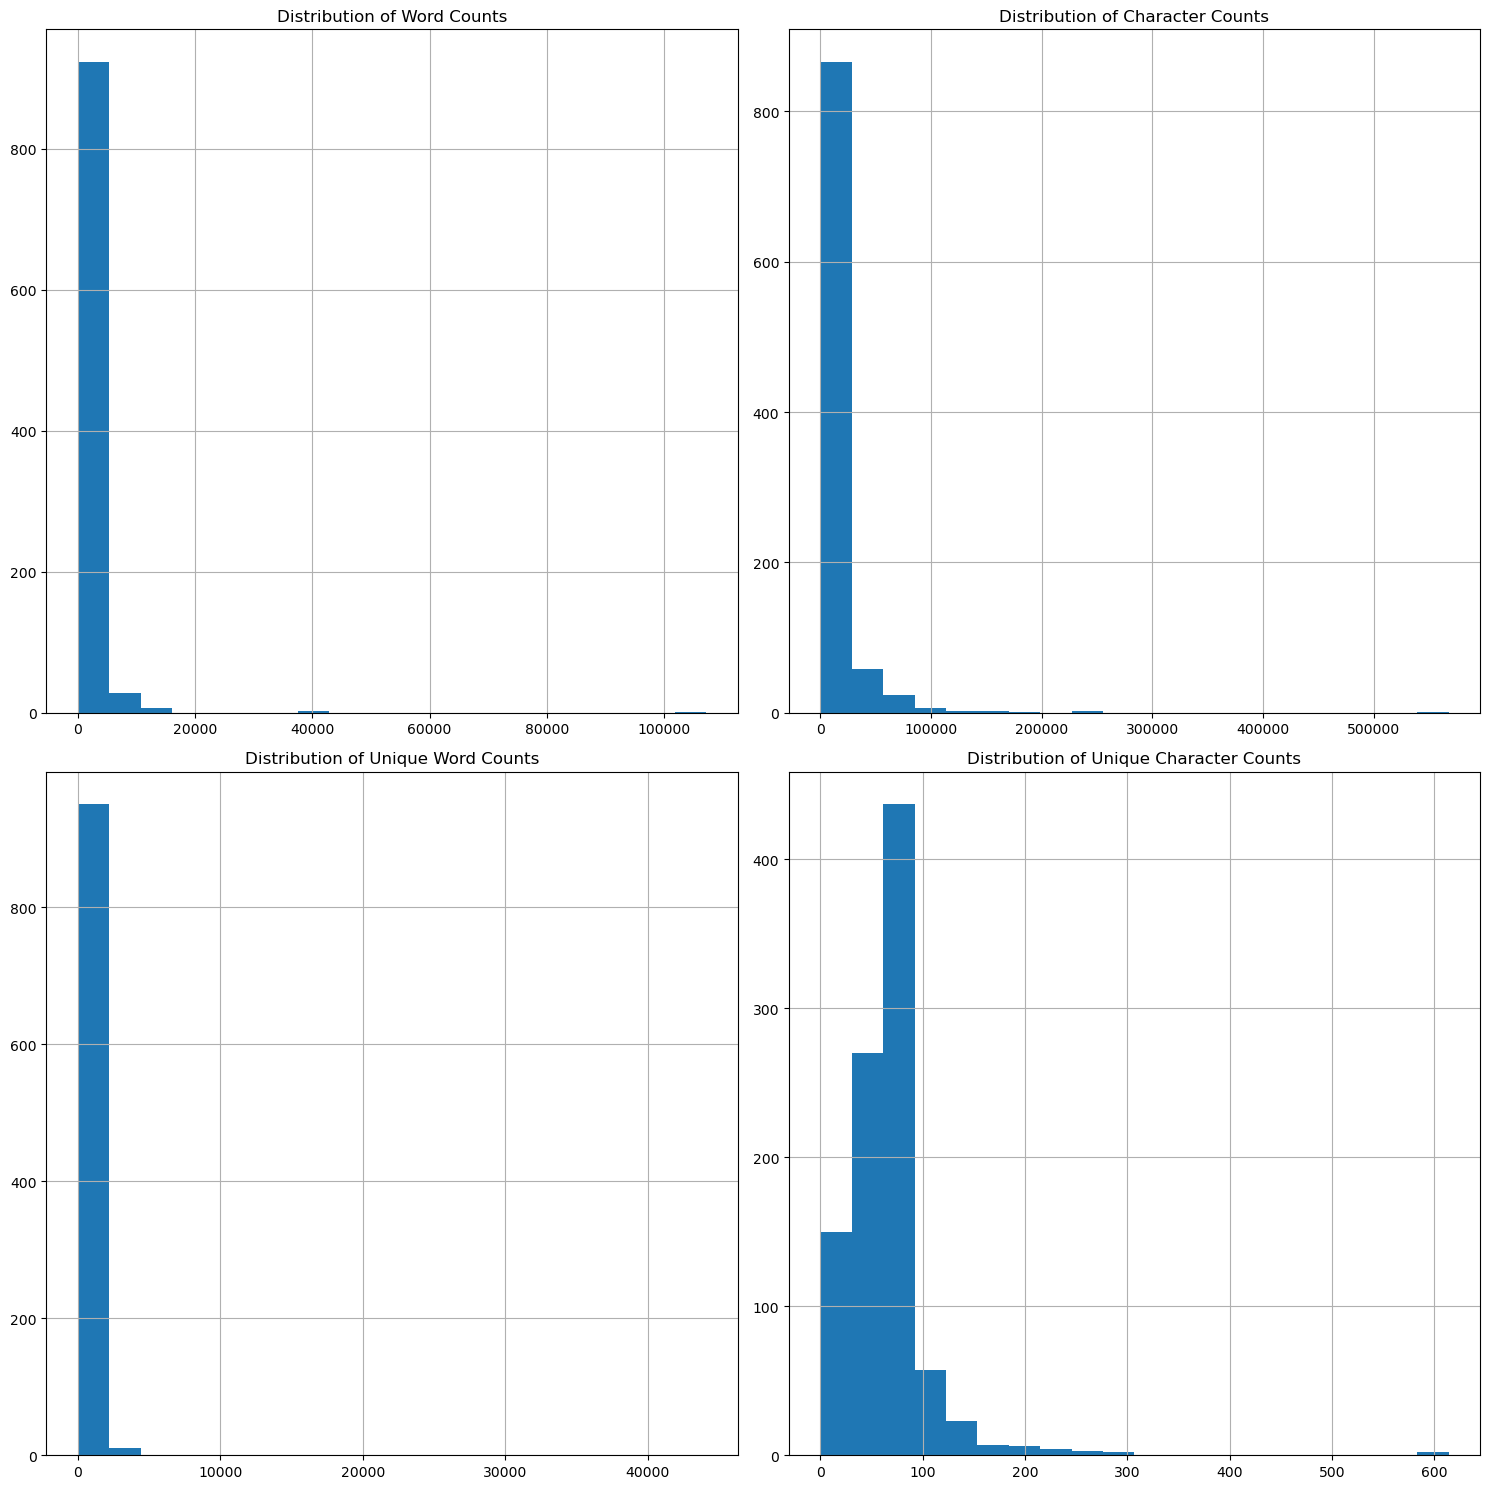


Top 10 most common words:
[('the', 21767), ('and', 15594), ('to', 15512), ('of', 13389), ('a', 11313), ('in', 8264), ('for', 6802), ('is', 6061), ('your', 4524), ('you', 4507)]

Top 10 most common characters:
[(' ', 5339466), ('\n', 1140315), ('e', 464927), ('a', 315972), ('o', 312401), ('t', 312279), ('i', 291499), ('n', 275937), ('r', 272851), ('s', 261720)]

Average word length: 6.03 characters


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Create a list to store the analysis results
analysis_results = []

for i, (text, label) in enumerate(zip(X, y)):
    # Count words and characters
    words = word_tokenize(text)
    chars = list(text)
    
    # Count unique words and characters
    unique_words = set(words)
    unique_chars = set(chars)
    
    # Store the results
    analysis_results.append({
        'File Index': i,
        'Label': label,
        'Word Count': len(words),
        'Character Count': len(chars),
        'Unique Word Count': len(unique_words),
        'Unique Character Count': len(unique_chars)
    })

# Convert to DataFrame for easy analysis
df = pd.DataFrame(analysis_results)

# Display summary statistics
print(df.describe())

# Plot histograms
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
df['Word Count'].hist(ax=axs[0, 0], bins=20)
axs[0, 0].set_title('Distribution of Word Counts')
df['Character Count'].hist(ax=axs[0, 1], bins=20)
axs[0, 1].set_title('Distribution of Character Counts')
df['Unique Word Count'].hist(ax=axs[1, 0], bins=20)
axs[1, 0].set_title('Distribution of Unique Word Counts')
df['Unique Character Count'].hist(ax=axs[1, 1], bins=20)
axs[1, 1].set_title('Distribution of Unique Character Counts')
plt.tight_layout()
plt.show()

# Display top 10 most common words and characters across all files
all_words = [word for text in X for word in text.split()]
all_chars = [char for text in X for char in list(text)]

print("\nTop 10 most common words:")
print(Counter(all_words).most_common(10))

print("\nTop 10 most common characters:")
print(Counter(all_chars).most_common(10))

# Calculate and display average word length
avg_word_length = sum(len(word) for word in all_words) / len(all_words)
print(f"\nAverage word length: {avg_word_length:.2f} characters")


In [7]:
# Analyze non-alphanumeric characters in files
non_alphanumeric_analysis = []

for i, text in enumerate(X):
    non_alphanumeric = set(char for char in text if not char.isalnum() and not char.isspace())
    if non_alphanumeric:
        non_alphanumeric_analysis.append({
            'File Index': i,
            'Non-alphanumeric Characters': list(non_alphanumeric)
        })

# List all unique non-alphanumeric characters
all_non_alphanumeric = set(char for item in non_alphanumeric_analysis for char in item['Non-alphanumeric Characters'])
print("All non-alphanumeric characters found:")
print(', '.join(sorted(all_non_alphanumeric)))


All non-alphanumeric characters found:
, , , , , , ,, , , , , , , , , , , , , , , !, ", #, $, %, &, ', (, ), *, +, ,, -, ., /, :, ;, <, =, >, ?, @, [, \, ], ^, _, `, {, |, }, ~, , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ¡, ¢, £, ¤, ¥, ¦, §, ¨, ©, «, ¬, ­, ®, ¯, °, ±, ´, ¶, ·, ¸, », ¿, ×, ÷, ˙, ˜, ̀, ́, ְ, ִ, ،, َ, ُ, ِ, ّ, ْ, ं, ़, ा, ि, ी, े, ै, ॉ, ो, ्, ।, ং, ়, া, ি, ী, ু, ৈ, ্, ਾ, ੀ, ੰ, ા, ી, ુ, ଼, ି, ா, ி, ீ, ு, ூ, ெ, ே, ை, ொ, ோ, ், ా, ు, ె, ్, ಂ, ಾ, ಿ, ೇ, ್, ം, ാ, ං, ්, ා, ැ, ි, ී, ු, ෙ, ේ, ො, ෝ, ෞ, ิ, ี, ื, ่, ာ, ်, ြ, ែ, ្, ​, ‌, ‍, ‎, ‏, ‐, ‑, ‒, –, —, ―, ‘, ’, ‚, “, ”, „, †, ‡, •, …, ‪, ‫, ‬, ‭, ‰, ′, ″, ‹, ›, ※, ⁠, €, ₱, ₹, №, ℠, ™, ←, ↑, →, ↓, ↔, ↵, ↺, ⇒, ⇗, ⇧, ∂, −, ∙, √, ∞, ∫, ≡, ≤, ⋅, ⌘, ⌥, ⏏, ⏰, └, ▲, ▸, ►, ▼, ▾, ◄, ○, ●, ☁, ☃, ★, ☆, ☢, ☰, ♀, ♥, ⚓, ⚖, ⚽, ⛄, ⛶, ✍, ✓, ✔, ✕, ✖, ✘, ✚, ✨, ❄, ❐, ❤, ❯, ➗, ➞, ➨, ⬈, ⭐, 、, 。, 《, 》, 「, 」, 【, 】, ・, , , , , , , , , , , , , , ️, ﻿, ！, （, ）, ，, ．, 


Total number of unique words across all files: 130241
Average length of unique words: 8.83 characters
Longest word length: 387 characters
Shortest word length: 1 characters


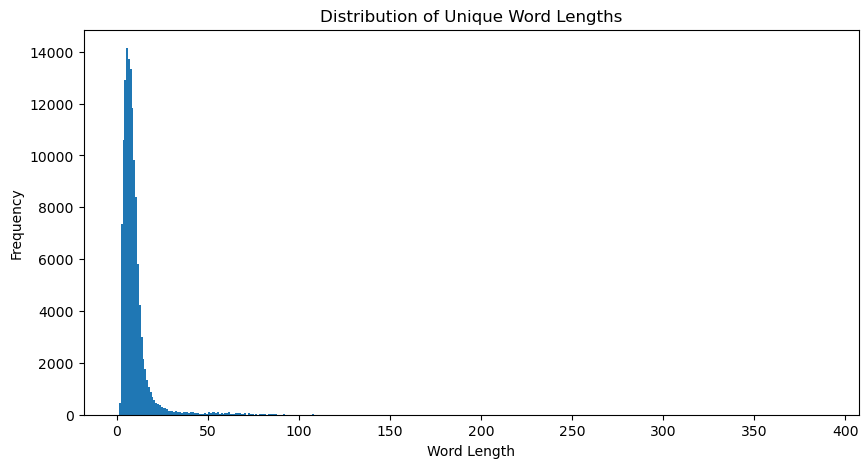


Examples of longest words (length 387):
2C.cRRsPvggk9sYRhWLV6rgnSiARrqbecx_c-3aH8I9OZBHGdO870-ovTrzoJmAiH4tF99EvVu-jJ1y4PJB0CcQsgpENPcH1FgHqOz_pjsWlnQqNE0LH9qYBzg5rCieEghI8A2Cvyc0hao-JBY_MYaPf7G6nPdD7gv_KBmSfeldXSMlT8pmEE7IpZkWPFVA0U06W6ZwFYSu3Gx5LMwsOhrYKGvLl6Hn7oFeo_8BTovrJStDtg6U1ffh4gUnjty4gxIlfrkY3talNrNpz1Yxog_YBX7h-PYS5eMdavQy1JzJJtIOLT73ZwUFSK_n7zFQ3Qcl6qRKXfHCZ1nNSBj4Qs4-kkOeGubA8K1h8EH3rXCIjNaLBLT-97YoRESK7LhWSgR7

Examples of shortest words (length 1):
å, ð, 중, Ï, В, Б, М, д, 🎄, −


In [8]:
# Analyze unique words across all files
all_unique_words = set(word for text in X for word in word_tokenize(text))

print(f"\nTotal number of unique words across all files: {len(all_unique_words)}")

# Display some statistics about word lengths
word_lengths = [len(word) for word in all_unique_words]
avg_word_length = sum(word_lengths) / len(word_lengths)
max_word_length = max(word_lengths)
min_word_length = min(word_lengths)

print(f"Average length of unique words: {avg_word_length:.2f} characters")
print(f"Longest word length: {max_word_length} characters")
print(f"Shortest word length: {min_word_length} characters")

# Display distribution of word lengths
plt.figure(figsize=(10, 5))
plt.hist(word_lengths, bins=range(min_word_length, max_word_length + 2, 1))
plt.title('Distribution of Unique Word Lengths')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.show()

# Display some examples of long and short words
long_words = [word for word in all_unique_words if len(word) == max_word_length]
short_words = [word for word in all_unique_words if len(word) == min_word_length]

print(f"\nExamples of longest words (length {max_word_length}):")
print(', '.join(long_words[:10]))  # Display up to 10 examples

print(f"\nExamples of shortest words (length {min_word_length}):")
print(', '.join(short_words[:10]))  # Display up to 10 examples


In [6]:
# Analyze non-ASCII words and their frequencies
from collections import Counter
import unicodedata

def is_ascii(s):
    return all(ord(c) < 128 for c in s)

non_ascii_words = [word for text in X for word in word_tokenize(text) if not is_ascii(word)]
non_ascii_word_freq = Counter(non_ascii_words)

print(f"Total number of unique non-ASCII words: {len(non_ascii_word_freq)}")

# Sort non-ASCII words by frequency (descending order)
sorted_non_ascii_words = sorted(non_ascii_word_freq.items(), key=lambda x: x[1], reverse=True)

print("\nTop 20 most frequent non-ASCII words and their frequencies:")
for word, freq in sorted_non_ascii_words[:20]:
    print(f"{word}: {freq}")

# Function to get Unicode category for a character
def get_unicode_category(char):
    return unicodedata.category(char)

# Analyze Unicode categories of non-ASCII characters
non_ascii_char_categories = Counter()
for word in non_ascii_words:
    for char in word:
        if not is_ascii(char):
            non_ascii_char_categories[get_unicode_category(char)] += 1

print("\nUnicode categories of non-ASCII characters:")
for category, count in non_ascii_char_categories.most_common():
    print(f"{category}: {count}")


Total number of unique non-ASCII words: 51441

Top 20 most frequent non-ASCII words and their frequencies:
’: 4401
“: 2268
”: 2268
»: 2263
‘: 1938
„: 1672
«: 1612
–: 761
·: 536
©: 517
‬: 477
‪: 458
•: 403
—: 376
в: 296
и: 266
×: 243
�: 226
€: 158
…: 156

Unicode categories of non-ASCII characters:
Ll: 137529
Lu: 73596
Lo: 60146
Po: 18561
So: 17979
No: 11123
Pf: 10620
Sc: 8533
Sk: 8430
Sm: 7749
Pi: 7470
Pd: 4732
Ps: 3395
Cf: 3019
Cc: 2034
Lm: 1717
Mc: 784
Mn: 670
Pe: 98
Co: 29
Nl: 10
Nd: 1


### Preprocessing

In [7]:
# Tokenization (character-level and word-level)
def tokenize_char(doc):
    return list(doc)  # Character-level tokenization

def tokenize_word(doc):
    return word_tokenize(doc)  # Word-level tokenization

def tokenize_word_ascii_only(text):
    # Tokenize the text into words
    words = word_tokenize(text)
    # Filter out non-ASCII words
    ascii_words = [word for word in words if is_ascii(word)]
    return ascii_words

char_sequences = [tokenize_char(_text) for _text in X]
word_sequences = [tokenize_word_ascii_only(_text) for _text in X] 

# Building the vocab from iterator
def yield_tokens(data_iter):
    for seq in data_iter:
        yield seq

char_vocab = build_vocab_from_iterator(yield_tokens(char_sequences), specials=["<unk>"])
word_vocab = build_vocab_from_iterator(yield_tokens(word_sequences), specials=["<unk>"])

# Setting default index for unknown tokens
char_vocab.set_default_index(char_vocab["<unk>"])
word_vocab.set_default_index(word_vocab["<unk>"])

# Check vocab
# print("Character Vocabulary:", char_vocab.get_stoi())  # String-to-index mapping
# print("Word Vocabulary:", word_vocab.get_stoi())  # String-to-index mapping


In [8]:
# Convert to numerical indices
char_indices = [[char_vocab[char] for char in seq] for seq in char_sequences]
word_indices = [[word_vocab[word] for word in seq] for seq in word_sequences]

# Convert to tensors and pad
char_indices = [torch.tensor(seq) for seq in char_indices]
word_indices = [torch.tensor(seq) for seq in word_indices]

char_padded = pad_sequence(char_indices, batch_first=True, padding_value=0)
word_padded = pad_sequence(word_indices, batch_first=True, padding_value=0)


In [9]:
import gc

# Perform garbage collection
gc.collect()

# Clear any unused memory cached by PyTorch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
embedding_dim = 5

# Embedding layers
char_embedding = nn.Embedding(len(char_vocab), embedding_dim)
#word_embedding = nn.Embedding(len(word_vocab), embedding_dim)

char_embedded = char_embedding(char_padded)
#word_embedded = word_embedding(word_padded)

# Concatenate embeddings
#concatenated = torch.cat((char_embedded, word_embedded), dim=1)

concatenated = char_embedded
print(concatenated.shape)

In [ ]:
class HTMLPhishCNN(nn.Module):
    def __init__(self, embedding_dim=5):
        super(HTMLPhishCNN, self).__init__()
        
        # 32 convolutional filters with 8 different kernel sizes
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=32, kernel_size=k) for k in [3, 5, 7]
        ])
        
        # Max Pooling layer
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # Placeholder for fully connected layer; dynamically set later
        self.fc = None
        
        # Output layer for binary classification
        self.output = nn.Linear(10, 1)
    
    def forward(self, x):
        # Apply Conv1D and ReLU to each layer
        x = [F.relu(conv(x.permute(0, 2, 1))) for conv in self.conv_layers]
        
        # Apply Max Pooling to each output
        x = [self.pool(conv) for conv in x]
        
        # Concatenate the output of all convolution layers along the sequence length
        x = torch.cat(x, dim=2)
        
        # Dynamically calculate the flattened size
        if self.fc is None:
            flatten_size = x.view(x.size(0), -1).size(1)
            self.fc = nn.Linear(flatten_size, 10)
        
        # Flatten the output
        x = x.view(x.size(0), -1)
        
        # Fully connected layer
        x = F.relu(self.fc(x))
        
        # Output layer (sigmoid for binary classification)
        x = torch.sigmoid(self.output(x))
        
        return x

# Example: create a model and pass the input
model = HTMLPhishCNN(5)

# Example input with shape [1, 4373, 100]
input_tensor = concatenated
output = model(input_tensor)
output # Should output the prediction for binary classification


In [ ]:
y = list(map(int, y))

In [ ]:
# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
num_epochs = 10

# Training loop
for epoch in tqdm.tqdm(range(num_epochs)):
    # Forward pass
    outputs = model(input_tensor)
    
    # Compute loss
    loss = criterion(outputs, y)
    
    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print progress
    if (epoch + 1) % 2 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Test the model
model.eval()
with torch.no_grad():
    test_output = model(input_tensor)
    predicted = (test_output > 0.5).float()
    accuracy = (predicted == y).float().mean()
    print(f'Test Accuracy: {accuracy.item():.4f}')

